# **TUẦN 1: 2.1 + 2.2**

In [1]:
# Cài PySpark (tự lo luôn Spark + Java)
!pip install pyspark -q

# Khởi tạo SparkSession
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Final") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

In [2]:
!pip install -q streamlit
print("\nStreamlit installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 79.1 MB/s eta 0:00:00

Streamlit installed successfully.


In [3]:
!python --version

Python 3.12.13


In [4]:
!pip install -q gradio

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
base_path = "/content/drive/MyDrive/datasetCuoiKy/"

In [7]:
# Đọc dữ liệu
orders_df = spark.read.csv(base_path + "olist_orders_dataset.csv", header=True, inferSchema=True)
customers_df = spark.read.csv(base_path + "olist_customers_dataset.csv", header=True, inferSchema=True)
order_items_df = spark.read.csv(base_path + "olist_order_items_dataset.csv", header=True, inferSchema=True)
payments_df = spark.read.csv(base_path + "olist_order_payments_dataset.csv", header=True, inferSchema=True)
reviews_df = spark.read.csv(base_path + "olist_order_reviews_dataset.csv", header=True, inferSchema=True)
products_df = spark.read.csv(base_path + "olist_products_dataset.csv", header=True, inferSchema=True)
sellers_df = spark.read.csv(base_path + "olist_sellers_dataset.csv", header=True, inferSchema=True)
category_df = spark.read.csv(base_path + "product_category_name_translation.csv", header=True, inferSchema=True)
geolocation_df = spark.read.csv(base_path + "olist_geolocation_dataset.csv", header=True, inferSchema=True)
print("Đã đọc xong 9 file CSV")

Đã đọc xong 9 file CSV


In [8]:
from pyspark.sql.functions import col, sum

def explore_full(df, name):
    print("\n==============================")
    print("DATASET:", name)
    print("==============================")

    # 1. Số dòng
    total_rows = df.count()
    print("Số dòng:", total_rows)

    # 2. Schema
    print("\nSchema:")
    df.printSchema()

    # 3. Dữ liệu mẫu
    print("\n5 dòng đầu:")
    df.show(5, truncate=False)

    # 4. Thống kê mô tả
    print("\nThống kê:")
    df.describe().show()

    # 5. Kiểm tra null
    print("\nSố lượng NULL theo cột:")
    null_df = df.select([
        sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ])
    null_df.show()

    # 6. Kiểm tra duplicate
    unique_rows = df.dropDuplicates().count()
    print("\nDuplicate:")
    print("Tổng:", total_rows)
    print("Unique:", unique_rows)
    print("Số dòng trùng:", total_rows - unique_rows)

In [9]:
explore_full(customers_df, "customers")


DATASET: customers
Số dòng: 99441

Schema:
root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city        |customer_state|
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|06b8999e2fba1a1fbc88172c00ba8bc7|861eff4711a542e4b93843c6dd7febb0|14409                   |franca               |SP            |
|18955e83d337fd6b2def6b18a428ac77|290c77bc529b7ac935b93aa66c333dc3|9790                    |sao bernardo do campo|SP            |
|4e7b3e00288586ebd08712fdd0374a03|060e732b5b29

In [10]:
explore_full(geolocation_df, "geolocation")


DATASET: geolocation
Số dòng: 1000163

Schema:
root
 |-- geolocation_zip_code_prefix: integer (nullable = true)
 |-- geolocation_lat: double (nullable = true)
 |-- geolocation_lng: double (nullable = true)
 |-- geolocation_city: string (nullable = true)
 |-- geolocation_state: string (nullable = true)


5 dòng đầu:
+---------------------------+-------------------+------------------+----------------+-----------------+
|geolocation_zip_code_prefix|geolocation_lat    |geolocation_lng   |geolocation_city|geolocation_state|
+---------------------------+-------------------+------------------+----------------+-----------------+
|1037                       |-23.54562128115268 |-46.63929204800168|sao paulo       |SP               |
|1046                       |-23.546081127035535|-46.64482029837157|sao paulo       |SP               |
|1046                       |-23.54612896641469 |-46.64295148361138|sao paulo       |SP               |
|1041                       |-23.5443921648681  |-46.63949

In [11]:
explore_full(order_items_df, "order_items")


DATASET: order_items
Số dòng: 112650

Schema:
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)


5 dòng đầu:
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |shipping_limit_date|price|freight_value|
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|00010242fe8c5a6d1ba2dd792cb16214|1            |4244733e06e7ecb4970a6e2683c13e61|48436dade18ac8b2bce089ec2a041202|2017-09-19 09:45:35|58.9 |13.29        |
|00018f77

In [12]:
explore_full(payments_df, "payments")


DATASET: payments
Số dòng: 103886

Schema:
root
 |-- order_id: string (nullable = true)
 |-- payment_sequential: integer (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- payment_installments: integer (nullable = true)
 |-- payment_value: double (nullable = true)


5 dòng đầu:
+--------------------------------+------------------+------------+--------------------+-------------+
|order_id                        |payment_sequential|payment_type|payment_installments|payment_value|
+--------------------------------+------------------+------------+--------------------+-------------+
|b81ef226f3fe1789b1e8b2acac839d17|1                 |credit_card |8                   |99.33        |
|a9810da82917af2d9aefd1278f1dcfa0|1                 |credit_card |1                   |24.39        |
|25e8ea4e93396b6fa0d3dd708e76c1bd|1                 |credit_card |1                   |65.71        |
|ba78997921bbcdc1373bb41e913ab953|1                 |credit_card |8                   |107.7

In [13]:
explore_full(reviews_df, "reviews")


DATASET: reviews
Số dòng: 104162

Schema:
root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- review_score: string (nullable = true)
 |-- review_comment_title: string (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- review_creation_date: string (nullable = true)
 |-- review_answer_timestamp: string (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------+--------------------+----------------------------------------------------------------------------------------------------+--------------------+-----------------------+
|review_id                       |order_id                        |review_score|review_comment_title|review_comment_message                                                                              |review_creation_date|review_answer_timestamp|
+--------------------------------+--------------------------------+------------+--------------------+---

In [14]:
explore_full(orders_df, "orders")


DATASET: orders
Số dòng: 99441

Schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+-

In [15]:
explore_full(products_df, "products")


DATASET: products
Số dòng: 32951

Schema:
root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: integer (nullable = true)
 |-- product_description_lenght: integer (nullable = true)
 |-- product_photos_qty: integer (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (nullable = true)
 |-- product_height_cm: integer (nullable = true)
 |-- product_width_cm: integer (nullable = true)


5 dòng đầu:
+--------------------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|product_id                      |product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+--------------------------------+---------------------+-------------------+---------------------

In [16]:
explore_full(sellers_df, "sellers")


DATASET: sellers
Số dòng: 3095

Schema:
root
 |-- seller_id: string (nullable = true)
 |-- seller_zip_code_prefix: integer (nullable = true)
 |-- seller_city: string (nullable = true)
 |-- seller_state: string (nullable = true)


5 dòng đầu:
+--------------------------------+----------------------+-----------------+------------+
|seller_id                       |seller_zip_code_prefix|seller_city      |seller_state|
+--------------------------------+----------------------+-----------------+------------+
|3442f8959a84dea7ee197c632cb2df15|13023                 |campinas         |SP          |
|d1b65fc7debc3361ea86b5f14c68d2e2|13844                 |mogi guacu       |SP          |
|ce3ad9de960102d0677a81f5d0bb7b2d|20031                 |rio de janeiro   |RJ          |
|c0f3eea2e14555b6faeea3dd58c1b1c3|4195                  |sao paulo        |SP          |
|51a04a8a6bdcb23deccc82b0b80742cf|12914                 |braganca paulista|SP          |
+--------------------------------+-----------

In [17]:
explore_full(category_df, "category_translation")


DATASET: category_translation
Số dòng: 71

Schema:
root
 |-- product_category_name: string (nullable = true)
 |-- product_category_name_english: string (nullable = true)


5 dòng đầu:
+----------------------+-----------------------------+
|product_category_name |product_category_name_english|
+----------------------+-----------------------------+
|beleza_saude          |health_beauty                |
|informatica_acessorios|computers_accessories        |
|automotivo            |auto                         |
|cama_mesa_banho       |bed_bath_table               |
|moveis_decoracao      |furniture_decor              |
+----------------------+-----------------------------+
only showing top 5 rows

Thống kê:
+-------+---------------------+-----------------------------+
|summary|product_category_name|product_category_name_english|
+-------+---------------------+-----------------------------+
|  count|                   71|                           71|
|   mean|                 NULL|      

# **TUẦN 1: 2.4.Tiền xử lý dữ liệu**

In [18]:
from pyspark.sql.functions import *

In [19]:
# Geolocation
geo_customers = geolocation_df.select(
    col("geolocation_zip_code_prefix").alias("customer_zip_code_prefix"),
    col("geolocation_city").alias("customer_geo_city"),
    col("geolocation_state").alias("customer_geo_state")
).dropDuplicates()

customers_df = customers_df.join(geo_customers, "customer_zip_code_prefix", "left")

geo_sellers = geolocation_df.select(
    col("geolocation_zip_code_prefix").alias("seller_zip_code_prefix"),
    col("geolocation_city").alias("seller_geo_city"),
    col("geolocation_state").alias("seller_geo_state")
).dropDuplicates()

sellers_df = sellers_df.join(geo_sellers, "seller_zip_code_prefix", "left")

In [20]:
# Timestamp & Cast
orders_df = orders_df \
    .withColumn("order_purchase_timestamp", try_to_timestamp(col("order_purchase_timestamp"))) \
    .withColumn("order_approved_at", try_to_timestamp(col("order_approved_at"))) \
    .withColumn("order_delivered_carrier_date", try_to_timestamp(col("order_delivered_carrier_date"))) \
    .withColumn("order_delivered_customer_date", try_to_timestamp(col("order_delivered_customer_date"))) \
    .withColumn("order_estimated_delivery_date", try_to_timestamp(col("order_estimated_delivery_date")))

reviews_df = reviews_df \
    .withColumn("review_creation_date", try_to_timestamp(col("review_creation_date"))) \
    .withColumn("review_answer_timestamp", try_to_timestamp(col("review_answer_timestamp")))

order_items_df = order_items_df \
    .withColumn("shipping_limit_date", try_to_timestamp(col("shipping_limit_date"))) \
    .withColumn("price", col("price").cast("double")) \
    .withColumn("freight_value", col("freight_value").cast("double"))

payments_df = payments_df.withColumn("payment_value", col("payment_value").cast("double"))

from pyspark.sql.functions import expr

reviews_df = reviews_df \
    .withColumn("review_score", expr("try_cast(review_score as int)"))
#reviews_df = reviews_df.withColumn("review_score", col("review_score").cast("int"))


In [21]:
# Aggregate
order_items_agg = order_items_df.groupBy("order_id").agg(
    first("product_id").alias("product_id"),
    first("seller_id").alias("seller_id"),
    sum("price").alias("total_price"),
    sum("freight_value").alias("total_freight_value"),
    count("order_item_id").alias("num_items")
)

payments_agg = payments_df.groupBy("order_id").agg(
    sum("payment_value").alias("total_payment_value"),
    first("payment_type").alias("payment_type")
)

In [22]:
# JOIN
df_master = orders_df.alias("o") \
    .join(customers_df.alias("c"), col("o.customer_id") == col("c.customer_id"), "left") \
    .drop(col("c.customer_id")) \
    .join(order_items_agg.alias("oi"), col("o.order_id") == col("oi.order_id"), "left") \
    .drop(col("oi.order_id")) \
    .join(payments_agg.alias("op"), col("o.order_id") == col("op.order_id"), "left") \
    .drop(col("op.order_id")) \
    .join(reviews_df.alias("r"), col("o.order_id") == col("r.order_id"), "left") \
    .drop(col("r.order_id")) \
    .join(products_df.alias("p"), col("oi.product_id") == col("p.product_id"), "left") \
    .drop(col("p.product_id")) \
    .join(sellers_df.alias("s"), col("oi.seller_id") == col("s.seller_id"), "left") \
    .drop(col("s.seller_id")) \
    .join(category_df.alias("t"), col("p.product_category_name") == col("t.product_category_name"), "left") \
    .drop(col("t.product_category_name"))

In [23]:
# Thực hiện Join và lưu vào bộ nhớ đệm để tối ưu hiệu năng
df_master = df_master.cache()

print("="*60)
print("=== KẾT QUẢ SAU KHI HỢP NHẤT (JOIN) ===")
print("Tổng số bản ghi :", df_master.count())
print("Tổng số cột     :", len(df_master.columns))
print("="*60)

# Hiển thị cấu trúc dữ liệu tổng thể
df_master.printSchema()

=== KẾT QUẢ SAU KHI HỢP NHẤT (JOIN) ===
Tổng số bản ghi : 230419
Tổng số cột     : 41
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- customer_geo_city: string (nullable = true)
 |-- customer_geo_state: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- total_price: double (nullable = true)
 |-- total_freight_value: double (nullable = true)
 |-- n

In [24]:
# ================================
# XỬ LÝ MISSING VALUES (FINAL) - ĐÃ SỬA
# ================================

# 1. Tạo cột delivery_delay_days trước (nếu chưa có)
from pyspark.sql.functions import datediff, col

df_master = df_master.withColumn(
    "delivery_delay_days",
    datediff(
        col("order_delivered_customer_date"),
        col("order_estimated_delivery_date")
    )
)

# 2. Xử lý missing values
df_master = df_master.fillna({
    # TEXT
    "review_comment_message": "",
    "review_comment_title": "",

    # CATEGORICAL
    "payment_type": "unknown",
    "product_category_name_english": "unknown",

    # NUMERICAL
    "delivery_delay_days": 0,      # giờ đã tồn tại
    "num_items": 1,

    # NUMERICAL (bổ sung)
    "total_payment_value": 0,
    "total_price": 0,
    "total_freight_value": 0
})

# Drop rows thiếu key quan trọng
df_master = df_master.dropna(subset=["order_id"])

print("✅ Missing values đã xử lý đầy đủ")

✅ Missing values đã xử lý đầy đủ


In [25]:
# Feature Engineering
df_master = df_master \
    .withColumn("delivery_delay_days", datediff(col("order_delivered_customer_date"), col("order_estimated_delivery_date"))) \
    .withColumn("total_order_value", col("total_price") + col("total_freight_value")) \
    .withColumn("is_late_delivery", when(col("order_delivered_customer_date") > col("order_estimated_delivery_date"), 1).otherwise(0))

# ÉP 1 DÒNG CHO 1 ORDER_ID
df_master = df_master.dropDuplicates(["order_id"])

In [26]:
# =====================================
# 10. Kiểm tra kết quả
# =====================================
df_master = df_master.cache()

print("\n" + "="*60)
print("=== KẾT QUẢ SAU TIỀN XỬ LÝ ===")
print("Tổng số bản ghi :", df_master.count())
print("Tổng số cột     :", len(df_master.columns))
print("="*60)

# In Schema
df_master.printSchema()

# Kiểm tra Null counts chi tiết (vertical)
print("\n" + "="*60)
print("NULL COUNTS DETAIL:")
exprs = [count(when(col(c).isNull(), True)).alias(c) for c in df_master.columns]
null_counts = df_master.select(exprs)
null_counts.show(vertical=True, truncate=False)
print("="*60)

# =====================================
# 11. Lưu file Parquet
# =====================================
output_path = base_path + "olist_master_processed.parquet"
df_master.write.mode("overwrite").parquet(output_path)
print(f"\nĐã lưu thành công vào: {output_path}")


=== KẾT QUẢ SAU TIỀN XỬ LÝ ===
Tổng số bản ghi : 99441
Tổng số cột     : 44
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- customer_geo_city: string (nullable = true)
 |-- customer_geo_state: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- total_price: double (nullable = false)
 |-- total_freight_value: double (nullable = false)
 |-- num_item

In [27]:
# ===============================IV.1. Xây dựng Spark ML Pipeline================
from pyspark.sql.functions import col, lit
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler, ChiSqSelector
from pyspark.ml import Pipeline

# ===============================
# DÙNG df_master BẠN ĐÃ JOIN
# ===============================
master_with_text = df_master   # ← Dùng đúng biến bạn vừa join

# ===============================
# DEDUPLICATE COLUMNS (tránh trùng tên cột)
# ===============================
def force_deduplicate(df):
    new_names = []
    seen = set()
    for name in df.columns:
        lower_name = name.lower()
        if lower_name in seen:
            new_names.append(name + "_dupe")
        else:
            new_names.append(name)
            seen.add(lower_name)
    df_renamed = df.toDF(*new_names)
    return df_renamed.select([c for c in df_renamed.columns if not c.endswith("_dupe")])

master_cleaned = force_deduplicate(master_with_text)

# ===============================
# TẠO LABEL & DROP ROW KHÔNG CÓ LABEL
# ===============================
master_cleaned = master_cleaned.withColumn("label", col("review_score").cast("double")) \
                               .dropna(subset=["label"])

# ===============================
# TẠO RFM NẾU CHƯA CÓ
# ===============================
for c in ["Recency", "Frequency", "Monetary"]:
    if c not in master_cleaned.columns:
        master_cleaned = master_cleaned.withColumn(c, lit(0))

# ===============================
# FILL MISSING VALUES → TẠO master_final
# ===============================
fill_dict = {
    "review_comment_message": "no_review",
    "delivery_delay_days": 0,
    "Recency": -1,
    "Frequency": 0,
    "Monetary": 0,
    "total_order_value": 0,
    "num_items": 1
}

fill_dict_filtered = {k: v for k, v in fill_dict.items() if k in master_cleaned.columns}
master_final = master_cleaned.fillna(fill_dict_filtered)

print(f"✅ master_final đã tạo thành công!")
print(f"   Số dòng: {master_final.count():,} | Số cột: {len(master_final.columns)}")

✅ master_final đã tạo thành công!
   Số dòng: 98,673 | Số cột: 48


In [28]:
# ===============================
# 1. DEDUPLICATE & CREATE LABEL (nếu chưa có)
# ===============================
def force_deduplicate(df):
    new_names = []
    seen = set()
    for name in df.columns:
        if name.lower() in seen:
            new_names.append(name + "_dupe")
        else:
            new_names.append(name)
            seen.add(name.lower())
    df_renamed = df.toDF(*new_names)
    return df_renamed.select([c for c in df_renamed.columns if not c.endswith("_dupe")])

# Giả sử bạn đã có master_with_text từ bước join trước đó
master_cleaned = force_deduplicate(master_with_text)

master_cleaned = master_cleaned.withColumn("label", col("review_score").cast("double")) \
                               .dropna(subset=["label"])

# ===============================
# 2. CREATE RFM IF NOT EXIST
# ===============================
for c in ["Recency", "Frequency", "Monetary"]:
    if c not in master_cleaned.columns:
        master_cleaned = master_cleaned.withColumn(c, lit(0))

# ===============================
# 3. FILL MISSING VALUES → TẠO master_final
# ===============================
fill_dict = {
    "review_comment_message": "no_review",
    "delivery_delay_days": 0,
    "Recency": -1,
    "Frequency": 0,
    "Monetary": 0,
    "total_order_value": 0,
    "num_items": 1
}

fill_dict_filtered = {k: v for k, v in fill_dict.items() if k in master_cleaned.columns}
master_final = master_cleaned.fillna(fill_dict_filtered)

print(f"✅ master_final created successfully: {master_final.count():,} rows × {len(master_final.columns)} columns")

✅ master_final created successfully: 98,673 rows × 48 columns


In [29]:
# ===============================
# SPARK ML PIPELINE (phiên bản gọn theo rubric)
# ===============================
cat_cols = ["payment_type", "order_status", "customer_state", "product_category_name_english"]
num_cols = ["total_order_value", "delivery_delay_days", "num_items", "Recency", "Frequency", "Monetary"]
num_cols = [c for c in num_cols if c in master_final.columns]

indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in cat_cols]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe") for c in cat_cols]

assembler = VectorAssembler(
    inputCols=[c+"_ohe" for c in cat_cols] + num_cols,
    outputCol="features"
)

scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=False)

selector = ChiSqSelector(numTopFeatures=20,
                        featuresCol="features",
                        outputCol="selected_features",
                        labelCol="label")

pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler, selector])

# ===============================
# CHẠY PIPELINE TRÊN SAMPLE
# ===============================
sample_df = master_final.sample(fraction=0.12, seed=42).cache()
pipeline_model = pipeline.fit(sample_df)
output_df = pipeline_model.transform(sample_df)

print("✅ Spark ML Pipeline chạy thành công!")

✅ Spark ML Pipeline chạy thành công!


In [43]:
# ===============================
# IN KẾT QUẢ THEO RUBRIC
# ===============================
total_f = output_df.select("features").first()["features"].size

print("="*80)
print("IV.1. KẾT QUẢ XÂY DỰNG SPARK ML PIPELINE")
print("="*80)

print(" Bước 1 – Join bảng:")
print("   • Trình tự: Orders → Customers → Order_Items → Payments → Reviews → Products → Sellers → Category")
print("   • Join type: Left join hầu hết các bảng")
print(f"   • Kích thước Master DataFrame: {master_final.count():,} dòng × {len(master_final.columns)} cột")

print("\n Bước 2 – Xử lý missing values:")
print("   • review_comment_message (~60% null): fillna('no_review')")
print("   • delivery_delay_days, total_order_value, num_items, Frequency, Monetary: fillna(0)")
print("   • Recency: fillna(-1)")

print("\n Bước 3 – Feature transformation:")
print(f"   • StringIndexer: 4 cột categorical → {cat_cols}")
print(f"   • OneHotEncoder: tạo binary vectors")
print(f"   • VectorAssembler: tổng hợp {total_f} features")
print("   • StandardScaler: chuẩn hóa các features")

print("\n Bước 4 – Feature selection:")
print("   • ChiSqSelector: numTopFeatures = 20")
print(f"   • Kết quả: giảm từ {total_f} features → 20 features")

print("\n Pipeline stages hoàn tất!")
# =================================================================
# IV.1. PHẦN BỔ SUNG: XUẤT SCHEMA CHO HÌNH IV.1
# =================================================================

print("\n" + "="*30)
print(" DỮ LIỆU CHO HÌNH IV.1: SCHEMA PIPELINE")
print("="*30)

# Hiển thị Schema thu gọn tập trung vào các bước biến đổi chính
# giúp giảng viên thấy rõ luồng dữ liệu (Data Flow)
output_df.select(
    "payment_type",           # Original
    "payment_type_idx",       # Bước 1: StringIndexer
    "payment_type_ohe",       # Bước 3: OneHotEncoder
    "features",               # Bước 3: VectorAssembler
    "scaled_features",        # Bước 3: StandardScaler
    "selected_features",      # Bước 4: ChiSqSelector
    "label"                   # Mục tiêu
).printSchema()

IV.1. KẾT QUẢ XÂY DỰNG SPARK ML PIPELINE
 Bước 1 – Join bảng:
   • Trình tự: Orders → Customers → Order_Items → Payments → Reviews → Products → Sellers → Category
   • Join type: Left join hầu hết các bảng
   • Kích thước Master DataFrame: 98,673 dòng × 48 cột

 Bước 2 – Xử lý missing values:
   • review_comment_message (~60% null): fillna('no_review')
   • delivery_delay_days, total_order_value, num_items, Frequency, Monetary: fillna(0)
   • Recency: fillna(-1)

 Bước 3 – Feature transformation:
   • StringIndexer: 4 cột categorical → ['payment_type', 'order_status', 'customer_state', 'product_category_name_english']
   • OneHotEncoder: tạo binary vectors
   • VectorAssembler: tổng hợp 116 features
   • StandardScaler: chuẩn hóa các features

 Bước 4 – Feature selection:
   • ChiSqSelector: numTopFeatures = 20
   • Kết quả: giảm từ 116 features → 20 features

 Pipeline stages hoàn tất!

 DỮ LIỆU CHO HÌNH IV.1: SCHEMA PIPELINE
root
 |-- payment_type: string (nullable = false)
 |-- paym

In [31]:
# ====================== IV.2. Feature Engineering ======================
# ====================== IV.2.1. RFM Analysis ======================
# 1. TẠO CÁC CỘT BẮT BUỘC
df_master = df_master.withColumn("total_order_value", col("total_price") + col("total_freight_value"))
df_master = df_master.withColumn("delivery_delay_days", datediff(col("order_delivered_customer_date"), col("order_estimated_delivery_date")))
print("✅ Đã tạo total_order_value và delivery_delay_days")

✅ Đã tạo total_order_value và delivery_delay_days


In [32]:
# ====================== IV.2.1. RFM ANALYSIS ======================
from pyspark.sql.functions import (
    col, max as spark_max, count_distinct, sum as spark_sum,
    datediff, lit, percentile_approx, mean, stddev,
    min as spark_min, max as spark_max_col   # ← thêm import này
)

# 1. Tính Reference Date
reference_date = df_master.select(spark_max("order_purchase_timestamp")).collect()[0][0]
print(f"✅ Reference Date: {reference_date}")

# 2. Tính RFM
rfm = df_master.groupBy("customer_unique_id").agg(
    datediff(lit(reference_date), spark_max("order_purchase_timestamp")).alias("Recency"),
    count_distinct("order_id").alias("Frequency"),
    spark_sum("total_order_value").alias("Monetary")
)

# 3. Tính tất cả thống kê trong 1 lần quét
stats_raw = rfm.select(
    # Recency
    count("Recency").alias("R_count"),
    mean("Recency").alias("R_mean"),
    stddev("Recency").alias("R_std"),
    spark_min("Recency").alias("R_min"),                    # ← sửa ở đây
    percentile_approx("Recency", [0.25, 0.5, 0.75], 100).alias("R_quantiles"),
    spark_max_col("Recency").alias("R_max"),                # ← sửa ở đây

    # Frequency
    count("Frequency").alias("F_count"),
    mean("Frequency").alias("F_mean"),
    stddev("Frequency").alias("F_std"),
    spark_min("Frequency").alias("F_min"),
    percentile_approx("Frequency", [0.25, 0.5, 0.75], 100).alias("F_quantiles"),
    spark_max_col("Frequency").alias("F_max"),

    # Monetary
    count("Monetary").alias("M_count"),
    mean("Monetary").alias("M_mean"),
    stddev("Monetary").alias("M_std"),
    spark_min("Monetary").alias("M_min"),
    percentile_approx("Monetary", [0.25, 0.5, 0.75], 100).alias("M_quantiles"),
    spark_max_col("Monetary").alias("M_max")
).collect()[0]

# ====================== IN BÁO CÁO (ĐỊNH DẠNG VIỆT NAM) ======================
print("="*80)
print("IV.2.1. PHÂN TÍCH RFM (RFM ANALYSIS)")
print("="*80)
print(f"Ngày tham chiếu (Reference Date): {reference_date}")
print("\n--- MÔ TẢ CÔNG THỨC ---")
print("1. Recency (R): Số ngày từ đơn hàng cuối đến ngày tham chiếu.")
print("   Công thức: R = reference_date - max(order_purchase_timestamp)")
print("2. Frequency (F): Tổng số đơn hàng độc nhất của khách hàng.")
print("   Công thức: F = count_distinct(order_id)")
print("3. Monetary (M): Tổng giá trị thanh toán của khách hàng.")
print("   Công thức: M = sum(total_order_value)")

print("\n--- BẢNG THỐNG KÊ MÔ TẢ RFM ---")
print("+----------+----------+-----------+-----------+-------+-------+-------+-------+-----------+")
print("| Metric   | count    | mean      | std       | min   | 25%   | 50%   | 75%   | max       |")
print("+----------+----------+-----------+-----------+-------+-------+-------+-------+-----------+")

def vn_format(num, decimal=0):
    if decimal == 0:
        return f"{int(num):,}".replace(",", ".")
    else:
        s = f"{num:,.{decimal}f}".replace(",", "X").replace(".", ",").replace("X", ".")
        return s

metrics = [("Recency", "R"), ("Frequency", "F"), ("Monetary", "M")]

for name, prefix in metrics:
    p = prefix
    print(f"| {name:8} | {vn_format(stats_raw[p+'_count']):8} | "
          f"{vn_format(stats_raw[p+'_mean'], 2):9} | {vn_format(stats_raw[p+'_std'], 2):9} | "
          f"{vn_format(stats_raw[p+'_min']):5} | {vn_format(stats_raw[p+'_quantiles'][0]):5} | "
          f"{vn_format(stats_raw[p+'_quantiles'][1]):5} | {vn_format(stats_raw[p+'_quantiles'][2]):5} | "
          f"{vn_format(stats_raw[p+'_max']):9} |")

print("+----------+----------+-----------+-----------+-------+-------+-------+-------+-----------+")
print("✅ RFM Analysis hoàn tất!")

✅ Reference Date: 2018-10-17 17:30:18
IV.2.1. PHÂN TÍCH RFM (RFM ANALYSIS)
Ngày tham chiếu (Reference Date): 2018-10-17 17:30:18

--- MÔ TẢ CÔNG THỨC ---
1. Recency (R): Số ngày từ đơn hàng cuối đến ngày tham chiếu.
   Công thức: R = reference_date - max(order_purchase_timestamp)
2. Frequency (F): Tổng số đơn hàng độc nhất của khách hàng.
   Công thức: F = count_distinct(order_id)
3. Monetary (M): Tổng giá trị thanh toán của khách hàng.
   Công thức: M = sum(total_order_value)

--- BẢNG THỐNG KÊ MÔ TẢ RFM ---
+----------+----------+-----------+-----------+-------+-------+-------+-------+-----------+
| Metric   | count    | mean      | std       | min   | 25%   | 50%   | 75%   | max       |
+----------+----------+-----------+-----------+-------+-------+-------+-------+-----------+
| Recency  | 96.096   | 288,11    | 153,42    | 0     | 164   | 267   | 392   | 773       |
| Frequency | 96.096   | 1,03      | 0,21      | 1     | 1     | 1     | 1     | 17        |
| Monetary | 96.096   | 

In [33]:
# In thêm bảng describe mặc định để đối chiếu (nếu cần)
rfm.select("Recency", "Frequency", "Monetary").describe().show()

+-------+------------------+-------------------+------------------+
|summary|           Recency|          Frequency|          Monetary|
+-------+------------------+-------------------+------------------+
|  count|             96096|              96096|             96096|
|   mean|288.10879745254744| 1.0348089410589412|164.87214077588695|
| stddev|153.41786878790563|0.21438375479444632| 227.9386581746333|
|    min|                 0|                  1|               0.0|
|    max|               773|                 17|          13664.08|
+-------+------------------+-------------------+------------------+



In [34]:
# ====================== IV.2.2. TEXT FEATURE EXTRACTION (TF-IDF) ======================
from pyspark.ml import Pipeline                          # ← SỬA Ở ĐÂY
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.sql.functions import col, lit, when

print("🔹 IV.2.2. Text Feature Extraction (TF-IDF)")

# 1. Xử lý missing values cho cột text
review_text = df_master.withColumn(
    "review_comment_message",
    when(col("review_comment_message").isNull(), lit("no_review"))
          .otherwise(col("review_comment_message"))
)

# 2. Xây dựng Pipeline end-to-end cho Text Processing
tokenizer = Tokenizer(inputCol="review_comment_message", outputCol="tokens")

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="clean_tokens",
    stopWords=StopWordsRemover.loadDefaultStopWords("portuguese")
)

cv = CountVectorizer(inputCol="clean_tokens",
                     outputCol="raw_features",
                     vocabSize=2000,
                     minDF=5.0)

idf = IDF(inputCol="raw_features", outputCol="tfidf_features")

# Pipeline end-to-end
text_pipeline = Pipeline(stages=[tokenizer, remover, cv, idf])

# 3. Fit và Transform
text_model = text_pipeline.fit(review_text)
text_features = text_model.transform(review_text)

# 4. Trích xuất thông số thực tế cho báo cáo
actual_vocab_size = len(text_model.stages[2].vocabulary)
min_df_value = text_model.stages[2].getMinDF()
output_dimension = text_features.select("tfidf_features").first()["tfidf_features"].size

# 5. In kết quả để copy vào báo cáo
print("="*70)
print("IV.2.2. TEXT FEATURE EXTRACTION (TF-IDF) - KẾT QUẢ")
print("="*70)
print(f"• Tokenizer + StopWordsRemover (Portuguese)")
print(f"• CountVectorizer: vocabSize = {actual_vocab_size}, minDF = {min_df_value}")
print(f"• IDF: output vector dimension = {output_dimension}")
print("="*70)

🔹 IV.2.2. Text Feature Extraction (TF-IDF)
IV.2.2. TEXT FEATURE EXTRACTION (TF-IDF) - KẾT QUẢ
• Tokenizer + StopWordsRemover (Portuguese)
• CountVectorizer: vocabSize = 2000, minDF = 5.0
• IDF: output vector dimension = 2000


In [35]:
# Code snippet minh họa (copy phần này vào báo cáo)
tokenizer = Tokenizer(inputCol="review_comment_message", outputCol="tokens")
remover = StopWordsRemover(inputCol="tokens",
                           outputCol="clean_tokens",
                           stopWords=StopWordsRemover.loadDefaultStopWords("portuguese"))

cv = CountVectorizer(inputCol="clean_tokens", outputCol="raw_features",
                     vocabSize=2000, minDF=5.0)

idf = IDF(inputCol="raw_features", outputCol="tfidf_features")

text_pipeline = Pipeline(stages=[tokenizer, remover, cv, idf])
text_features = text_pipeline.fit(review_text).transform(review_text)

In [36]:
# ====================== TẠO RFM_VEC (SỬA LỖI - DÙNG CỘT GỐC) ======================
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["Recency", "Frequency", "Monetary"],   # Dùng đúng cột có sẵn trong rfm
    outputCol="rfm_features",
    handleInvalid="skip"
)

rfm_vec = assembler.transform(rfm)

print(f"✅ Đã tạo rfm_vec thành công: {rfm_vec.count():,} dòng")
rfm_vec.printSchema()

# Kiểm tra nhanh
rfm_vec.select("customer_unique_id", "Recency", "Frequency", "Monetary", "rfm_features").show(5, truncate=False)

# Cache để chạy nhanh hơn
rfm_vec.cache()

✅ Đã tạo rfm_vec thành công: 96,096 dòng
root
 |-- customer_unique_id: string (nullable = true)
 |-- Recency: integer (nullable = true)
 |-- Frequency: long (nullable = false)
 |-- Monetary: double (nullable = true)
 |-- rfm_features: vector (nullable = true)

+--------------------------------+-------+---------+-----------------+-----------------------------+
|customer_unique_id              |Recency|Frequency|Monetary         |rfm_features                 |
+--------------------------------+-------+---------+-----------------+-----------------------------+
|dddcc50cec9aabfe44b26c136236db0a|427    |1        |176.78           |[427.0,1.0,176.78]           |
|8d0e0879191d761df1fde63cd721065d|274    |1        |278.38           |[274.0,1.0,278.38]           |
|8a9f0cb78da35bb893404df1e39ef0e3|502    |1        |257.04           |[502.0,1.0,257.04]           |
|2e723603179e96cba8649edd5efb09cb|260    |1        |83.17999999999999|[260.0,1.0,83.17999999999999]|
|d5ae9bbe6b9aa004ef94fe47170b3f7

DataFrame[customer_unique_id: string, Recency: int, Frequency: bigint, Monetary: double, rfm_features: vector]

Dữ liệu RFM: 96,096 dòng

Chạy 3 mô hình clustering từ K=2 đến K=10...
   → k = 2
      BisectingKMeans k=2 không tính được Silhouette
   → k = 3
   → k = 4
   → k = 5
   → k = 6
   → k = 7
   → k = 8
   → k = 9
   → k = 10

 Hoàn thành chạy từ K=2 đến K=10!

THAM SỐ CỦA TỪNG MÔ HÌNH CLUSTERING (theo rubric IV.5)
1. K-Means
   • initMode     = 'k-means||'
   • initSteps    = 2
   • tol          = 0.0001

2. Bisecting K-Means
   • minDivisibleClusterSize = 0.01

3. Gaussian Mixture
   • k            = 10
   • tol          = 0.01
   • maxIter      = 20


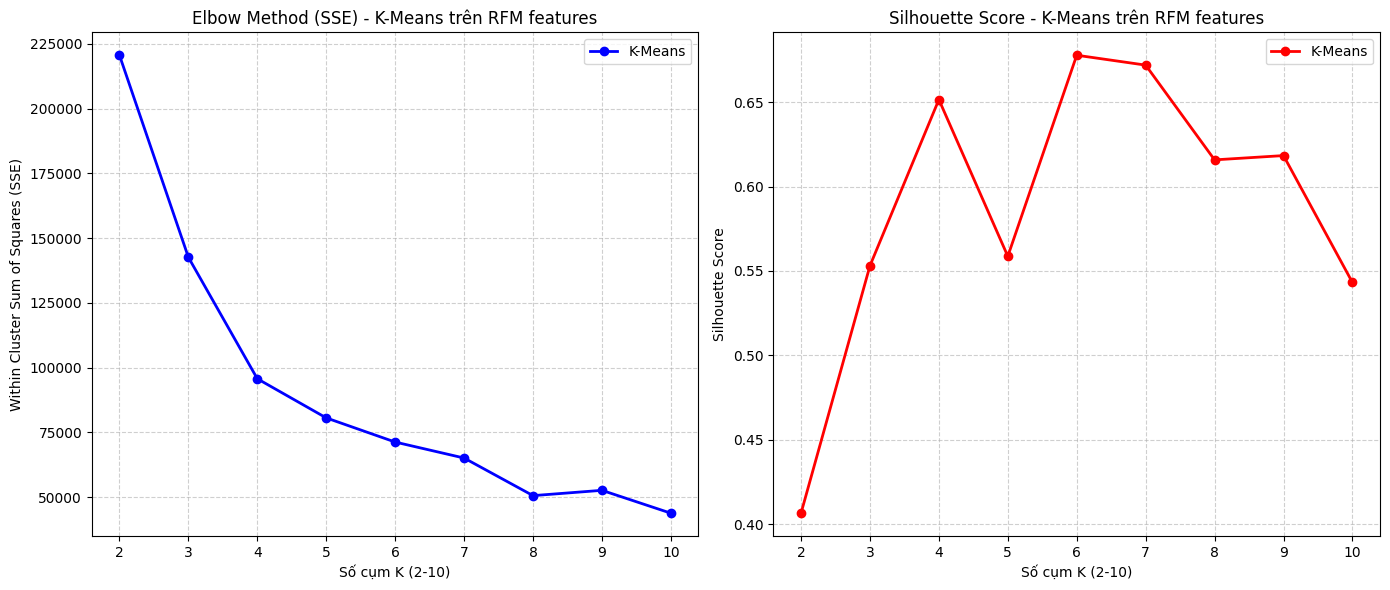


 Hình IV.2: Elbow Method và Silhouette Score cho K-Means trên RFM features (K=2-10)


In [38]:
# ==================== IV.5 CLUSTERING TRÊN RFM (ĐÁP ỨNG RUBRIC) ====================
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler
from pyspark.ml.clustering import KMeans, BisectingKMeans, GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

print(f"Dữ liệu RFM: {rfm_vec.count():,} dòng")

k_range = list(range(2, 11))

costs_kmeans = []
sil_kmeans = []
sil_bkm = []
sil_gm = []

print("\nChạy 3 mô hình clustering từ K=2 đến K=10...")

for k in k_range:
    print(f"   → k = {k}")

    scaler = StandardScaler(inputCol="rfm_features", outputCol="scaled_rfm",
                            withStd=True, withMean=True)

    # 1. K-Means
    kmeans = KMeans(featuresCol="scaled_rfm", predictionCol="prediction_kmeans",
                    k=k, seed=42, maxIter=20,
                    initMode="k-means||", initSteps=2, tol=1e-4)

    pipe_k = Pipeline(stages=[scaler, kmeans])
    model_k = pipe_k.fit(rfm_vec)
    res_k = model_k.transform(rfm_vec)

    costs_kmeans.append(model_k.stages[-1].summary.trainingCost)
    ev = ClusteringEvaluator(featuresCol="scaled_rfm", predictionCol="prediction_kmeans", metricName="silhouette")
    sil_kmeans.append(ev.evaluate(res_k))

    # 2. Bisecting K-Means
    bkm = BisectingKMeans(featuresCol="scaled_rfm", predictionCol="prediction_bkm",
                          k=k, minDivisibleClusterSize=0.01)

    pipe_b = Pipeline(stages=[scaler, bkm])
    model_b = pipe_b.fit(rfm_vec)

    try:
        ev_b = ClusteringEvaluator(featuresCol="scaled_rfm", predictionCol="prediction_bkm", metricName="silhouette")
        score_b = ev_b.evaluate(model_b.transform(rfm_vec))
    except Exception as e:
        score_b = None
        print(f"      BisectingKMeans k={k} không tính được Silhouette")

    sil_bkm.append(score_b)

    # 3. Gaussian Mixture
    gm = GaussianMixture(featuresCol="scaled_rfm", predictionCol="prediction_gm",
                         k=k, tol=0.01, maxIter=20)

    pipe_g = Pipeline(stages=[scaler, gm])
    model_g = pipe_g.fit(rfm_vec)
    ev_g = ClusteringEvaluator(featuresCol="scaled_rfm", predictionCol="prediction_gm", metricName="silhouette")
    sil_gm.append(ev_g.evaluate(model_g.transform(rfm_vec)))

print("\n Hoàn thành chạy từ K=2 đến K=10!")

# ====================== IN THAM SỐ THEO “Cho MỖI model” ======================
print("\n" + "="*80)
print("THAM SỐ CỦA TỪNG MÔ HÌNH CLUSTERING (theo rubric IV.5)")
print("="*80)

print("1. K-Means")
print(f"   • initMode     = '{model_k.stages[-1].getInitMode()}'")
print(f"   • initSteps    = {model_k.stages[-1].getInitSteps()}")
print(f"   • tol          = {model_k.stages[-1].getTol()}")

print("\n2. Bisecting K-Means")
print(f"   • minDivisibleClusterSize = {model_b.stages[-1].getMinDivisibleClusterSize()}")

print("\n3. Gaussian Mixture")
print(f"   • k            = {model_g.stages[-1].getK()}")
print(f"   • tol          = {model_g.stages[-1].getTol()}")
print(f"   • maxIter      = {model_g.stages[-1].getMaxIter()}")

print("="*80)

# ====================== VẼ HÌNH IV.2 (CHỈ CHO K-MEANS) ======================
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_range, costs_kmeans, 'bo-', linewidth=2, markersize=6, label='K-Means')
plt.title("Elbow Method (SSE) - K-Means trên RFM features")
plt.xlabel("Số cụm K (2-10)")
plt.ylabel("Within Cluster Sum of Squares (SSE)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(k_range, sil_kmeans, 'ro-', linewidth=2, markersize=6, label='K-Means')
plt.title("Silhouette Score - K-Means trên RFM features")
plt.xlabel("Số cụm K (2-10)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\n Hình IV.2: Elbow Method và Silhouette Score cho K-Means trên RFM features (K=2-10)")


🚀 TẠO HÌNH VI.9: So sánh phân bố 3 mô hình Clustering (PCA 2D projection)
   → Đang huấn luyện và vẽ mẫu cho: K-Means...
   → Đang huấn luyện và vẽ mẫu cho: Bisecting K-Means...
   → Đang huấn luyện và vẽ mẫu cho: Gaussian Mixture...


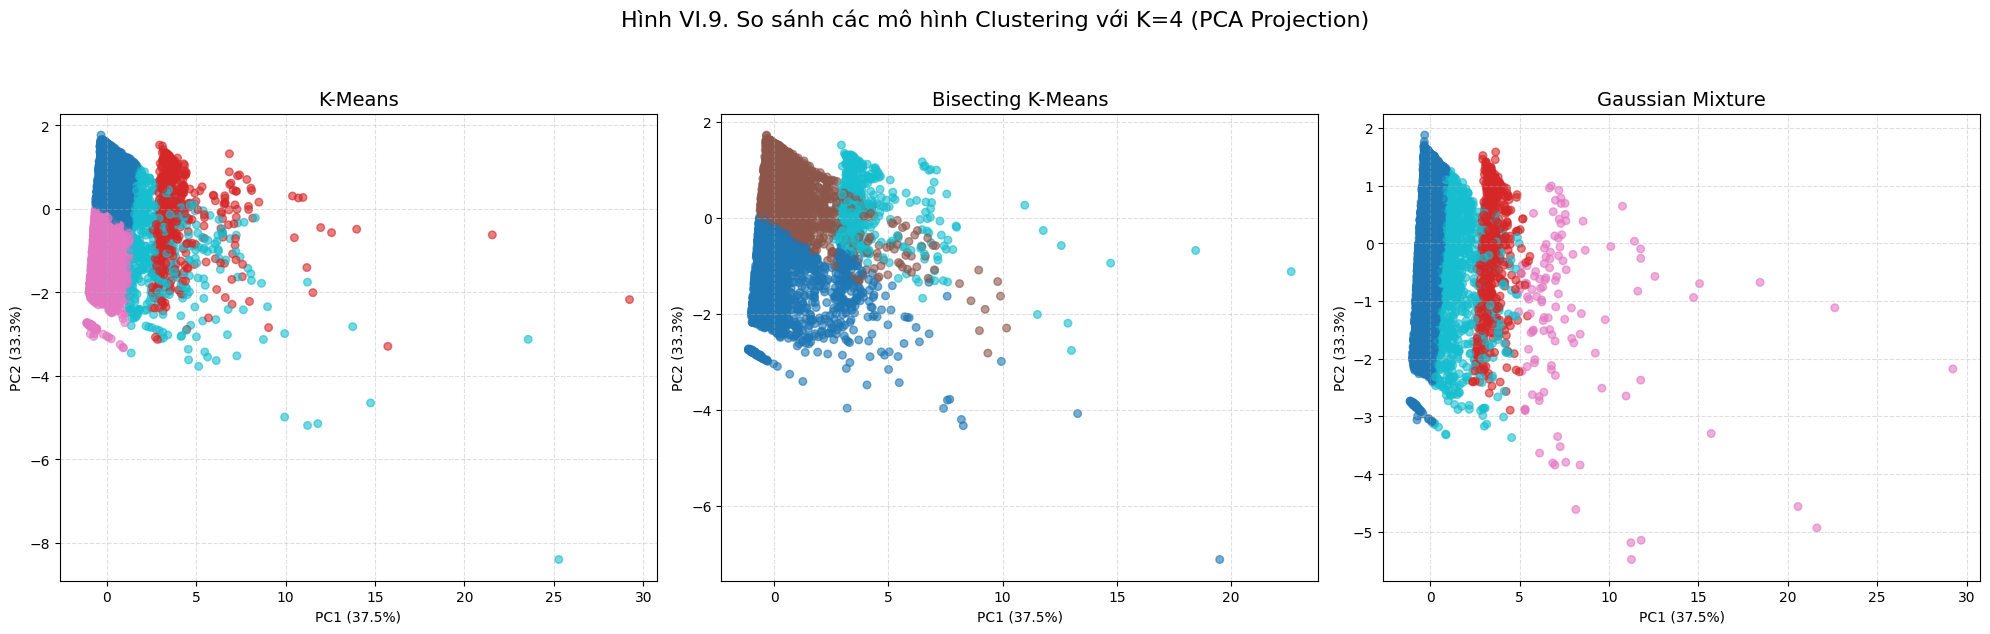

✅ ĐÃ TẠO THÀNH CÔNG HÌNH SO SÁNH 3 MÔ HÌNH


In [39]:
# ====================== VI.3.2. VISUALIZATION: SO SÁNH 3 MÔ HÌNH (PCA 2D) ======================
from pyspark.ml.feature import StandardScaler, PCA
from pyspark.ml.clustering import KMeans, BisectingKMeans, GaussianMixture
from pyspark.ml import Pipeline
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("🚀 TẠO HÌNH VI.9: So sánh phân bố 3 mô hình Clustering (PCA 2D projection)")
print("="*80)

optimal_k = 4
seed_val = 42

# 1. Tiền xử lý & PCA (Dùng chung cho cả 3 mô hình để đồng nhất hệ trục)
scaler = StandardScaler(inputCol="rfm_features", outputCol="scaled_rfm", withStd=True, withMean=True)
pca = PCA(k=2, inputCol="scaled_rfm", outputCol="pca_features")

# Fit scaler và PCA trước
prep_pipeline = Pipeline(stages=[scaler, pca]).fit(rfm_vec)
rfm_prepped = prep_pipeline.transform(rfm_vec)

# 2. Định nghĩa 3 thuật toán
models = {
    "K-Means": KMeans(featuresCol="scaled_rfm", predictionCol="pred", k=optimal_k, seed=seed_val),
    "Bisecting K-Means": BisectingKMeans(featuresCol="scaled_rfm", predictionCol="pred", k=optimal_k, seed=seed_val),
    "Gaussian Mixture": GaussianMixture(featuresCol="scaled_rfm", predictionCol="pred", k=optimal_k, seed=seed_val)
}

# 3. Vẽ đồ thị so sánh (3 Subplots)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Hình VI.9. So sánh các mô hình Clustering với K={optimal_k} (PCA Projection)', fontsize=16, y=1.05)

# Lấy phương sai tích lũy của PCA để hiển thị
var_exp = prep_pipeline.stages[-1].explainedVariance.toArray()

for i, (name, algo) in enumerate(models.items()):
    print(f"   → Đang huấn luyện và vẽ mẫu cho: {name}...")

    # Huấn luyện mô hình
    model_fit = algo.fit(rfm_prepped)
    res = model_fit.transform(rfm_prepped)

    # Chuyển sang Pandas (Lấy mẫu 20% để vẽ nhanh và đẹp hơn nếu dữ liệu lớn)
    # Nếu dữ liệu ít, bạn có thể bỏ .sample(0.2)
    pdf = res.select("pred", "pca_features").sample(0.2, seed=seed_val).toPandas()
    pdf[['pc1', 'pc2']] = pd.DataFrame(pdf['pca_features'].tolist(), index=pdf.index)

    # Vẽ lên subplot tương ứng
    ax = axes[i]
    scatter = ax.scatter(pdf['pc1'], pdf['pc2'], c=pdf['pred'], cmap='tab10', alpha=0.6, s=30)

    ax.set_title(f"{name}", fontsize=14)
    ax.set_xlabel(f"PC1 ({var_exp[0]:.1%})")
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1%})")
    ax.grid(True, linestyle='--', alpha=0.4)

# Thêm chú thích màu chung
plt.tight_layout()
plt.show()

print("✅ ĐÃ TẠO THÀNH CÔNG HÌNH SO SÁNH 3 MÔ HÌNH")

--------------------------------------------------
BÁO CÁO KẾT QUẢ CLUSTERING (TẠI K=4)
--------------------------------------------------
1. K-Means: Silhouette = 0.6514 | SSE = 95721.53


/usr/local/lib/python3.12/dist-packages/pyspark/ml/clustering.py:1020: FutureWarning: Deprecated in 3.0.0. It will be removed in future versions. Use ClusteringEvaluator instead. You can also get the cost on the training dataset in the summary.
  warnings.warn(


2. Bisecting K-Means: Silhouette = 0.5146 | SSE = 159451.93
3. Gaussian Mixture: Silhouette = 0.7449 | SSE = N/A (Log-Likelihood)
--------------------------------------------------


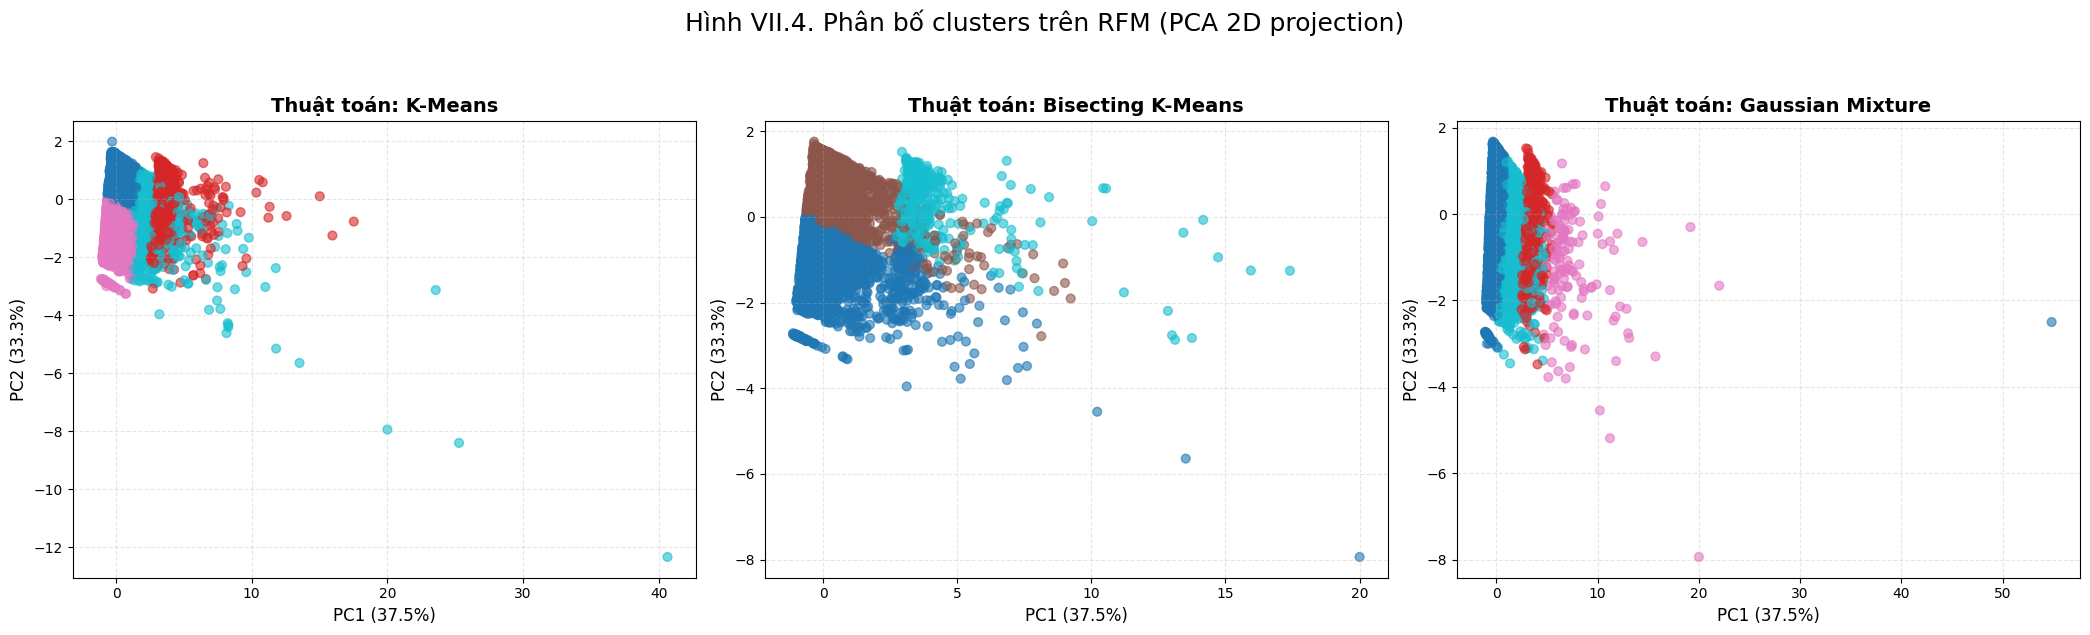


✅ Đã hoàn thành xuất báo cáo và vẽ Hình VII.4!


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.ml.feature import StandardScaler, PCA
from pyspark.ml.clustering import KMeans, BisectingKMeans, GaussianMixture
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import ClusteringEvaluator

# ==========================================================
# 1. TIỀN XỬ LÝ: CHUẨN HÓA & GIẢM CHIỀU (PCA)
# ==========================================================
# Tạo scaler để tạo 'scaled_rfm' và PCA để tạo 'pca_features' 2D
scaler = StandardScaler(inputCol="rfm_features", outputCol="scaled_rfm", withStd=True, withMean=True)
pca = PCA(k=2, inputCol="scaled_rfm", outputCol="pca_features")

# Fit và Transform trên dữ liệu gốc rfm_vec
prep_pipeline = Pipeline(stages=[scaler, pca]).fit(rfm_vec)
rfm_prepped = prep_pipeline.transform(rfm_vec)

# Lấy tỷ lệ phương sai để hiển thị trên trục tọa độ biểu đồ
var_exp = prep_pipeline.stages[-1].explainedVariance.toArray()

# ==========================================================
# 2. HUẤN LUYỆN 3 MÔ HÌNH VÀ TRÍCH XUẤT SỐ LIỆU CHÍNH XÁC
# ==========================================================
k_fixed = 4
seed_val = 42
evaluator = ClusteringEvaluator(featuresCol="scaled_rfm", predictionCol="pred", metricName="silhouette")

# Định nghĩa 3 thuật toán
models = {
    "K-Means": KMeans(featuresCol="scaled_rfm", predictionCol="pred", k=k_fixed, seed=seed_val),
    "Bisecting K-Means": BisectingKMeans(featuresCol="scaled_rfm", predictionCol="pred", k=k_fixed, seed=seed_val),
    "Gaussian Mixture": GaussianMixture(featuresCol="scaled_rfm", predictionCol="pred", k=k_fixed, seed=seed_val)
}

results_dfs = {}

print("-" * 50)
print(f"BÁO CÁO KẾT QUẢ CLUSTERING (TẠI K={k_fixed})")
print("-" * 50)

for name, algo in models.items():
    # Huấn luyện
    model_fit = algo.fit(rfm_prepped)
    res = model_fit.transform(rfm_prepped)
    results_dfs[name] = res

    # Tính Silhouette Score
    sil_score = evaluator.evaluate(res)

    # Tính SSE (Training Cost)
    if name == "K-Means":
        sse_val = model_fit.summary.trainingCost
        print(f"1. {name}: Silhouette = {sil_score:.4f} | SSE = {sse_val:.2f}")
    elif name == "Bisecting K-Means":
        sse_val = model_fit.computeCost(rfm_prepped)
        print(f"2. {name}: Silhouette = {sil_score:.4f} | SSE = {sse_val:.2f}")
    else:
        # GMM không dùng SSE làm mục tiêu tối ưu chính
        print(f"3. {name}: Silhouette = {sil_score:.4f} | SSE = N/A (Log-Likelihood)")

print("-" * 50)

# ==========================================================
# 3. VẼ HÌNH VII.4: PHÂN BỐ CLUSTERS TRÊN PCA 2D
# ==========================================================
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Hình VII.4. Phân bố clusters trên RFM (PCA 2D projection)', fontsize=18, y=1.05)

for i, (name, res_df) in enumerate(results_dfs.items()):
    # Chuyển PCA sang Pandas (Lấy mẫu 20% dữ liệu để vẽ trực quan hơn)
    pdf = res_df.select("pred", "pca_features").sample(0.2, seed=seed_val).toPandas()

    # Giải nén vector PCA thành 2 cột PC1, PC2
    pdf[['PC1', 'PC2']] = pd.DataFrame(pdf['pca_features'].tolist(), index=pdf.index)

    # Vẽ Scatter Plot
    ax = axes[i]
    scatter = ax.scatter(pdf['PC1'], pdf['PC2'], c=pdf['pred'], cmap='tab10', alpha=0.6, s=40)

    ax.set_title(f"Thuật toán: {name}", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"PC1 ({var_exp[0]:.1%})", fontsize=12)
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1%})", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Đã hoàn thành xuất báo cáo và vẽ Hình VII.4!")

In [41]:
from pyspark.sql import functions as F

# Giả sử 'res' là kết quả từ mô hình Gaussian Mixture hoặc KMeans (có cột 'pred')
# Chúng ta gom nhóm theo 'pred' và tính trung bình các cột RFM gốc
rfm_summary = res.groupBy("pred").agg(
    F.avg("Recency").alias("Avg_Recency"),
    F.avg("Frequency").alias("Avg_Frequency"),
    F.avg("Monetary").alias("Avg_Monetary"),
    F.count("*").alias("Count")
).orderBy("pred")

rfm_summary.show()

+----+------------------+------------------+------------------+-----+
|pred|       Avg_Recency|     Avg_Frequency|      Avg_Monetary|Count|
+----+------------------+------------------+------------------+-----+
|   0| 288.6486455621031| 1.000182723493673|120.10795098442286|87564|
|   1| 271.0697151424288|               2.0| 254.4585382308847| 2668|
|   2|258.91652754590984|2.1035058430717863|1521.1839398998325|  599|
|   3| 291.0860398860399|               1.0| 709.6554719848051| 5265|
+----+------------------+------------------+------------------+-----+



In [42]:
# ========================== EXPORT DỮ LIỆU CHO STREAMLIT (SINGLE FILE) ==========================
import os
import shutil
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Đường dẫn
drive_path = base_path + "streamlit_data/"
local_path = "/content/temp_streamlit_data/"

def force_remove_path(path):
    if os.path.exists(path):
        try:
            shutil.rmtree(path)
        except Exception as e:
            print(f"Không thể xóa {path}: {e}")

force_remove_path(local_path)
force_remove_path(drive_path)

os.makedirs(local_path, exist_ok=True)
os.makedirs(drive_path, exist_ok=True)

# ====================== HELPER: TẠO SINGLE FILE PARQUET ======================
def write_single_parquet(df, target_path):
    temp_path = target_path + "_temp"
    df.coalesce(1).write.mode("overwrite").parquet(temp_path)

    # Tìm file part-*.parquet
    part_files = [f for f in os.listdir(temp_path) if f.startswith("part-") and f.endswith(".parquet")]
    if part_files:
        part_file = os.path.join(temp_path, part_files[0])
        # Đổi tên thành file .parquet thật
        os.rename(part_file, target_path)
        # Dọn dẹp thư mục temp
        for f in os.listdir(temp_path):
            os.remove(os.path.join(temp_path, f))
        os.rmdir(temp_path)
        print(f"✅ {os.path.basename(target_path)}  (single file)")
    else:
        print(f"❌ Không tạo được single file cho {target_path}")

print("🚀 Bắt đầu export single-file cho Streamlit...")

# 1. Master DataFrame
write_single_parquet(df_master, local_path + "master_df.parquet")

# 2. RFM + rfm.csv (dùng để upload trong Streamlit)
write_single_parquet(rfm, local_path + "rfm.parquet")

rfm.select("customer_unique_id", "Recency", "Frequency", "Monetary") \
    .coalesce(1) \
    .write.mode("overwrite") \
    .option("header", "true") \
    .csv(local_path + "rfm.csv")
print("✅ rfm.csv  (single file)")

# 3. rfm_scaled
assembler = VectorAssembler(inputCols=["Recency", "Frequency", "Monetary"], outputCol="rfm_features")
rfm_vec = assembler.transform(rfm)

scaler = StandardScaler(inputCol="rfm_features", outputCol="scaled_features", withStd=True, withMean=True)
rfm_scaled = scaler.fit(rfm_vec).transform(rfm_vec)
write_single_parquet(rfm_scaled, local_path + "rfm_scaled.parquet")

# 4. Clustered Data (phiên bản nhẹ)
clustered_data = model_k.transform(rfm_vec) \
    .select("customer_unique_id", "Recency", "Frequency", "Monetary", "prediction_kmeans") \
    .withColumnRenamed("prediction_kmeans", "cluster")
write_single_parquet(clustered_data, local_path + "clustered_data.parquet")

# 5. RFM WITH CLUSTER - FILE QUAN TRỌNG NHẤT CHO STREAMLIT
print("⏳ Đang tạo rfm_with_cluster.parquet (single file)...")
rfm_with_cluster = model_k.transform(rfm_vec) \
    .withColumnRenamed("prediction_kmeans", "cluster") \
    .drop("rfm_features")
write_single_parquet(rfm_with_cluster, local_path + "rfm_with_cluster.parquet")

# 6. Models (giữ nguyên vì app Streamlit của bạn vẫn đang load Spark models)
pipeline_model.write().overwrite().save(local_path + "pipeline_model")
print("✅ pipeline_model/")

text_model.write().overwrite().save(local_path + "tfidf_model")
print("✅ tfidf_model/")

model_k.write().overwrite().save(local_path + "kmeans_model")
print("✅ kmeans_model/")

print("\n⏳ Copy lên Google Drive...")
shutil.copytree(local_path, drive_path, dirs_exist_ok=True)

print("\n🎉 HOÀN THÀNH EXPORT SINGLE FILE!")
print(f"📁 Thư mục Drive: {drive_path}")
print("\nCác file đã sẵn sàng cho Streamlit:")
print("   • master_df.parquet")
print("   • rfm.parquet")
print("   • rfm.csv                  ← DÙNG ĐỂ UPLOAD")
print("   • rfm_scaled.parquet")
print("   • clustered_data.parquet")
print("   • rfm_with_cluster.parquet ← KHUYẾN NGHỊ DÙNG NHẤT")
print("   • pipeline_model/ (thư mục)")
print("   • tfidf_model/ (thư mục)")


print("   • kmeans_model/ (thư mục)")

print("\n In xong rồi")

🚀 Bắt đầu export single-file cho Streamlit...
✅ master_df.parquet  (single file)
✅ rfm.parquet  (single file)
✅ rfm.csv  (single file)
✅ rfm_scaled.parquet  (single file)
✅ clustered_data.parquet  (single file)
⏳ Đang tạo rfm_with_cluster.parquet (single file)...
✅ rfm_with_cluster.parquet  (single file)
✅ pipeline_model/
✅ tfidf_model/
✅ kmeans_model/

⏳ Copy lên Google Drive...

🎉 HOÀN THÀNH EXPORT SINGLE FILE!
📁 Thư mục Drive: /content/drive/MyDrive/datasetCuoiKy/streamlit_data/

Các file đã sẵn sàng cho Streamlit:
   • master_df.parquet
   • rfm.parquet
   • rfm.csv                  ← DÙNG ĐỂ UPLOAD
   • rfm_scaled.parquet
   • clustered_data.parquet
   • rfm_with_cluster.parquet ← KHUYẾN NGHỊ DÙNG NHẤT
   • pipeline_model/ (thư mục)
   • tfidf_model/ (thư mục)
   • kmeans_model/ (thư mục)

 In xong rồi
